# 实验009：两层绘图台的形状与数值审计

先修008、004。先在纸上预测结果，再重启内核、清空输出、从上到下执行。

固定行样本约定：X为(N,D)、W为(D,H)、b为(H,)或(1,H)。所有数据为原创合成，输入V、内部响应R、输出mm。不训练模型，无API、网络或GPU依赖。

本Notebook与experiment.py共用经过严格检查的接口；另以手算、三层循环和Fraction检查数值。发布时使用新进程真实IPython InProcessKernel执行，未测试浏览器Jupyter或socket传输。

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
from experiment import (load_case, linear, affine, compose_affine,
                        broadcast_evidence, run)
print({"python": sys.version.split()[0], "numpy": np.__version__})
print("Local data exists:", Path("data/plotter.json").is_file())

{'python': '3.12.14', 'numpy': '2.3.5'}
Local data exists: True


## A. 先记录shape与单位

参数矩阵的行是输入特征，列是输出通道。b1的三项是三个内部通道共享偏置，不是三条样本专属偏移。请先手算P02的通道C。

In [2]:
metadata, arrays = load_case()
X, W1, b1, W2, b2 = (arrays[k] for k in ("X", "W1", "b1", "W2", "b2"))
for name, value in arrays.items():
    print(name, value.shape, "\n", value)
assert X.shape == (3,2) and W1.shape == (2,3)
assert W2.shape == (3,2)
print("Units: X V; W1 R/V; b1 R; W2 mm/R; b2 mm")

X (3, 2) 
 [[ 1.  2.]
 [ 0. -1.]
 [ 3.  1.]]
W1 (2, 3) 
 [[ 1.  2. -1.]
 [ 2.  0.  1.]]
b1 (3,) 
 [ 1.  -2.   0.5]
W2 (3, 2) 
 [[ 1.   0. ]
 [ 0.5  2. ]
 [-2.   1. ]]
b2 (2,) 
 [-1.  3.]
Units: X V; W1 R/V; b1 R; W2 mm/R; b2 mm


## B. 循环中的每一个索引

n选样本，k选输出，j遍历被累加的输入特征。下面不在循环内调用@，先比较shape，再比较数值。

In [3]:
Z_loop = np.zeros((X.shape[0], W1.shape[1]))
for n in range(X.shape[0]):
    for k in range(W1.shape[1]):
        for j in range(X.shape[1]):
            Z_loop[n, k] += X[n,j] * W1[j,k]
Z1 = linear(X, W1)
assert Z_loop.shape == Z1.shape == (3,3)
np.testing.assert_allclose(Z_loop, Z1, rtol=1e-12, atol=1e-12)
print("Z1 / R =\n", Z1)
np.testing.assert_allclose(Z1, [[5,2,1],[-2,0,-1],[5,6,-2]])
np.testing.assert_allclose(linear(X[[2,0,1]],W1), Z1[[2,0,1]])
print("Single-row output:", linear(X[0:1],W1).shape)

Z1 / R =
 [[ 5.  2.  1.]
 [-2.  0. -1.]
 [ 5.  6. -2.]]
Single-row output: (1, 3)


## A续. 第一层偏置与第二层输出

每个偏置按列共享。先解释P02水平坐标中的(-0.5)×(-2)为何是正数，再读输出。

In [4]:
U = affine(X, W1, b1)
UW2 = linear(U, W2)
Y = affine(U, W2, b2)
for name, value, unit in [("U",U,"R"),("UW2",UW2,"mm"),("Y",Y,"mm")]:
    print(name, value.shape, unit, "\n", value)
np.testing.assert_allclose(Y, [[2,4.5],[-2,-1.5],[10,9.5]])
print("parameter count =", W1.size+b1.size+W2.size+b2.size)

U (3, 3) R 
 [[ 6.   0.   1.5]
 [-1.  -2.  -0.5]
 [ 6.   4.  -1.5]]
UW2 (3, 2) mm 
 [[ 3.   1.5]
 [-1.  -4.5]
 [11.   6.5]]
Y (3, 2) mm 
 [[ 2.   4.5]
 [-2.  -1.5]
 [10.   9.5]]
parameter count = 17


## C. 两层可以合并，偏置必须继续经过W2

Wc=W1@W2；bc=b1@W2+b2。结合律保持矩阵先后顺序。整数和二分数中心例子可精确表示，其他有理数测试使用显式容差。

In [5]:
Wc, bc = compose_affine(W1,b1,W2,b2)
Y_fused = affine(X,Wc,bc)
assert Y_fused.shape == Y.shape
np.testing.assert_allclose(Y_fused,Y,rtol=1e-12,atol=1e-12)
np.testing.assert_allclose((X@W1)@W2, X@(W1@W2),rtol=1e-12,atol=1e-12)
print("Wc / (mm/V):", Wc.tolist())
print("bc / mm:",bc.tolist())
print("maximum absolute composition difference:",float(np.max(np.abs(Y-Y_fused))))
print("W2@W1 has a different shape:",(W2@W1).shape)

Wc / (mm/V): [[4.0, 3.0], [0.0, 1.0]]
bc / mm: [-2.0, -0.5]
maximum absolute composition difference: 0.0
W2@W1 has a different shape: (3, 3)


## D. 基像在W的行里，转置反转书写顺序

这里x明确保留(1,2)，故转置后真是(2,1)。一维数组的.T不会产生新轴。图用最终线性部分Wc，不含bc。

basis images: [[1.0, 2.0, -1.0], [2.0, 0.0, 1.0]]
transpose product shape: (3, 1)
1D transpose shape: (2,)
X.T@X aggregates across samples: [[10.0, 5.0], [5.0, 6.0]]


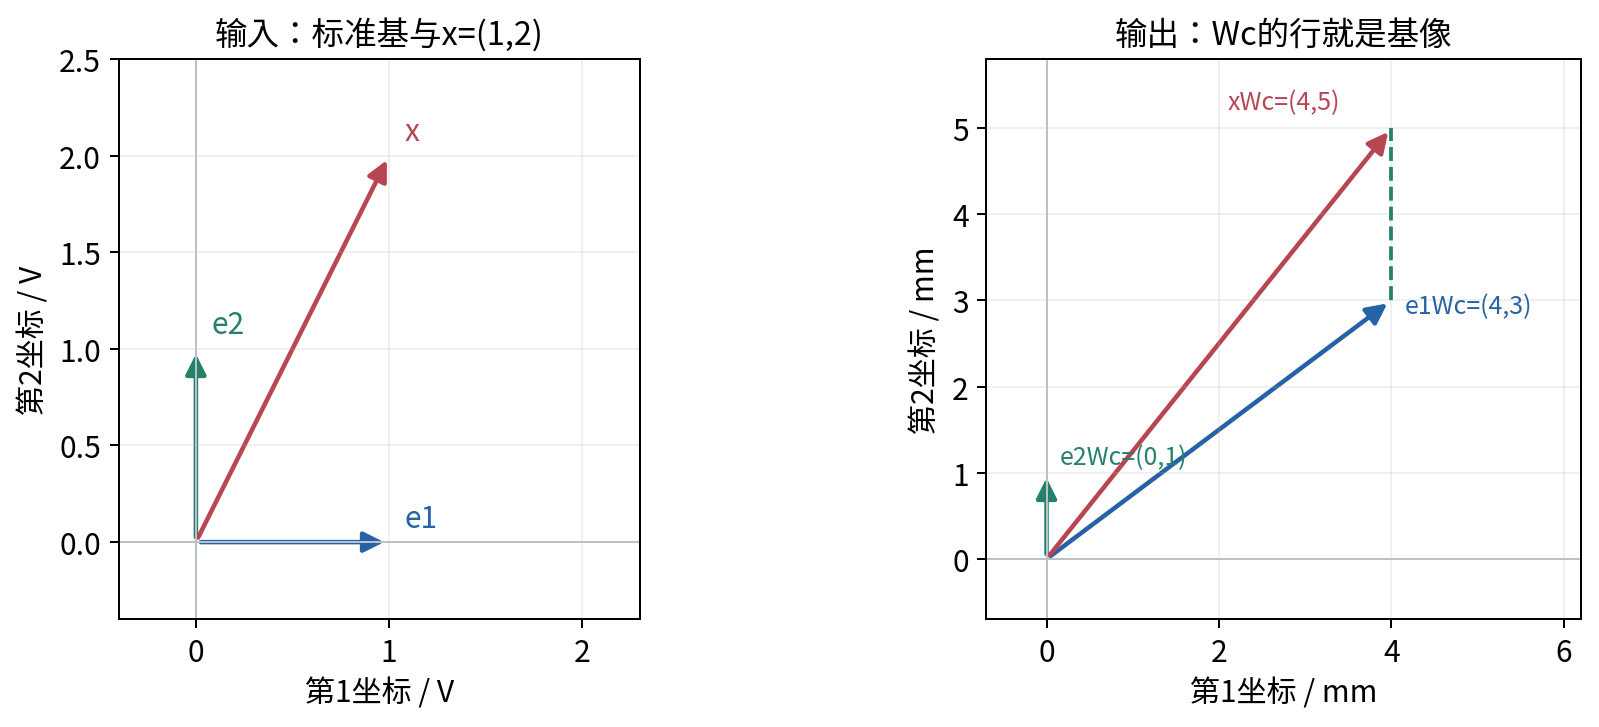

In [6]:
E = np.eye(2)
np.testing.assert_allclose(E@W1,W1)
x = X[2:3]
np.testing.assert_allclose(x@W1,3*W1[0:1]+W1[1:2])
np.testing.assert_allclose((x@W1).T,W1.T@x.T)
print("basis images:", (E@W1).tolist())
print("transpose product shape:", (x@W1).T.shape)
print("1D transpose shape:",np.array([1,2]).T.shape)
print("X.T@X aggregates across samples:",(X.T@X).tolist())
from IPython.display import display, Image
display(Image(filename="figures/03_basis.png", width=800))

## E. N=H会隐藏错误偏置轴

下面的wrong故意错误但能运行。严格函数拒绝它。再把N改为2，原始错误广播才会报错；这说明不能依赖维数巧合来查错。

In [7]:
wrong = X@W1 + b1[:,None]
print("wrong:",wrong.tolist())
print("correct:",U.tolist())
print("same shape:",wrong.shape==U.shape)
print("max absolute error:",float(np.max(np.abs(wrong-U))))
for title, call in [
    ("strict bias contract", lambda: affine(X,W1,b1[:,None])),
    ("N=2 raw broadcasting", lambda: X[:2]@W1+b1[:,None]),
]:
    try:
        call()
    except ValueError as exc:
        print(title, type(exc).__name__, str(exc))
    else:
        raise AssertionError("expected a ValueError")

wrong: [[6.0, 3.0, 2.0], [-4.0, -2.0, -3.0], [5.5, 6.5, -1.5]]
correct: [[6.0, 0.0, 1.5], [-1.0, -2.0, -0.5], [6.0, 4.0, -1.5]]
same shape: True
max absolute error: 3.0
strict bias contract ValueError b must have shape (3,) or (1, 3)
N=2 raw broadcasting ValueError operands could not be broadcast together with shapes (2,3) (3,1) 


## F. 广播视图不等于显式复制

不尝试修改广播视图。nbytes是逻辑元素字节总数，不能直接当新增内存。加法输出仍有存储需求。

In [8]:
evidence = broadcast_evidence(b1,3)
print(json.dumps(evidence,ensure_ascii=False,indent=2))
view = np.broadcast_to(b1,(3,3))
copied = np.tile(b1,(3,1))
np.testing.assert_array_equal(view,copied)
assert np.shares_memory(view,b1)
assert not np.shares_memory(copied,b1)
assert not view.flags.writeable

{
  "same_values": true,
  "broadcast_shares_memory": true,
  "tile_shares_memory": false,
  "broadcast_writeable": false,
  "bias_storage_bytes": 24,
  "expanded_logical_nbytes": 72,
  "explicit_tile_nbytes": 72,
  "broadcast_strides": [
    0,
    8
  ],
  "note": "view.nbytes describes logical elements, not new allocated storage; addition still allocates a result"
}


## G. 改括号与换顺序不同；转置与撤销也不同

S、T是另一个无量纲二维反例，不是偷偷替换绘图台参数。每行仍是一条输入。

In [9]:
S=np.array([[2.,0.],[0.,1.]])
T=np.array([[1.,1.],[0.,1.]])
p=np.array([[1.,1.]])
print("ST:",(S@T).tolist(),"TS:",(T@S).tolist())
print("pST:",(p@S@T).tolist(),"pTS:",(p@T@S).tolist())
assert not np.array_equal(S@T,T@S)
print("pSS.T:",(p@S@S.T).tolist())
undo_S=np.diag([.5,1.])
np.testing.assert_allclose(p@S@undo_S,p)

ST: [[2.0, 2.0], [0.0, 1.0]] TS: [[2.0, 1.0], [0.0, 1.0]]
pST: [[2.0, 3.0]] pTS: [[2.0, 2.0]]
pSS.T: [[4.0, 1.0]]


## G续. 只改变一个参数

复制后再改动。一个权重的影响由对应输入值调节；共享偏置平移每条样本相同量。

In [10]:
W_changed=W1.copy()
W_changed[0,1] += .25
weight_delta=linear(X,W_changed)-Z1
bias_delta=affine(X,W1,b1+np.array([0,.25,0]))-U
print("weight change:",weight_delta.tolist())
print("bias change:",bias_delta.tolist())
np.testing.assert_allclose(weight_delta[:,1],[.25,0,.75])
np.testing.assert_allclose(bias_delta[:,1],[.25,.25,.25])
np.testing.assert_allclose(W1,[[1,2,-1],[2,0,1]])

weight change: [[0.0, 0.25, 0.0], [0.0, 0.0, 0.0], [0.0, 0.75, 0.0]]
bias change: [[0.0, 0.25, 0.0], [0.0, 0.25, 0.0], [0.0, 0.25, 0.0]]


## I. 新指令、中点与原点

新指令保留批次维。f(0)=bc说明偏置非零时不线性；中点保持并不代表角度保持。

In [11]:
new_x=np.array([[2.,-1.]])
new_Z=linear(new_x,W1)
new_U=affine(new_x,W1,b1)
new_Y=affine(new_U,W2,b2)
print("new Z,U,Y:",new_Z.tolist(),new_U.tolist(),new_Y.tolist())
np.testing.assert_allclose(new_Y,affine(new_x,Wc,bc))
np.testing.assert_allclose(new_Y,[[6,4.5]])
mid=(X[0:1]+X[1:2])/2
mid_Y=affine(mid,Wc,bc)
np.testing.assert_allclose(mid_Y,(Y[0:1]+Y[1:2])/2)
print("midpoint:",mid_Y.tolist())
print("origin image:",affine(np.zeros((1,2)),Wc,bc).tolist())
print("basis-image dot product:",float(Wc[0]@Wc[1]))

new Z,U,Y: [[0.0, 4.0, -3.0]] [[1.0, 2.0, -2.5]] [[6.0, 4.5]]
midpoint: [[0.0, 1.5]]
origin image: [[-2.0, -0.5]]
basis-image dot product: 3.0


## H. 精确分数与完整失败测试

测试模块使用独立三层循环累加Fraction，64组确定性有理数夹具覆盖不同批次和非方阵。这里只把预期失败捕获为证据，不忽略未知错误。

In [12]:
from test_experiment import run_tests, exact_affine
exact_U=exact_affine(metadata["X"],metadata["W1"],metadata["b1"])
exact_Y=exact_affine(exact_U,metadata["W2"],metadata["b2"])
print("Exact Y:",[[str(v) for v in row] for row in exact_Y])
test_report=run_tests()
print(json.dumps(test_report,ensure_ascii=False,indent=2))

Exact Y: [['2', '9/2'], ['-2', '-3/2'], ['10', '19/2']]
{
  "status": "passed",
  "groups": [
    "central hand arrays and independent Fraction oracle",
    "64 rational fixtures across non-square shapes and N=1",
    "basis rows, linearity, affine combination, origin and differences",
    "noncommutativity, transpose is not inverse, wrong-axis aggregation",
    "shared bias broadcasting, explicit copy, square-batch silent error",
    "parameter changes, shared bias shifts and row independence",
    "20 rejected shape, type, mixed-boolean, finite-input and overflow cases"
  ],
  "rational_fixtures": 64,
  "exact_Y_mm": [
    [
      "2",
      "9/2"
    ],
    [
      "-2",
      "-3/2"
    ],
    [
      "10",
      "19/2"
    ]
  ],
  "rtol": 1e-12,
  "atol": 1e-12
}


## 保存运行证据

保存路径与命令行脚本分开，便于核对两次新会话输出是否一致。结论应包含正确数值、形状契约、静默错误和不能推出的现实结论。

In [13]:
report=run(Path("notebook_outputs"))
print("saved:",sorted(p.name for p in Path("notebook_outputs").iterdir()))
assert report["arrays"]["Y"] == Y.tolist()
print("Completed fixed-rule checks. No training or real-device performance claim.")

saved: ['environment.json', 'positions_mm.csv', 'report.json']
Completed fixed-rule checks. No training or real-device performance claim.


## 结论与自检

P02输出为(-2,-1.5)mm，逐层、合成与分数检查一致。批次不改变共享参数；行基像对应W的行。错误偏置列在N=H时能通过shape检查，所以还要核对语义和独立答案。广播视图与复制可以同值但不同存储。测试通过不证明任意输入、硬件、真实设备精度或训练效果。

对照lab.pdf任务A至I与answers.pdf，补上自己的手算、初次错误及修正原因。